# Testing Sparse Auto Encoder (SAE)

In principal, it should be possible to extract hidden feature vectors from embedding outputs using a sparse auto-encoder (SAE) to disentangle the superimposed features for a given set of neural activation outputs. To test the validity of using a SAE for this purpose, the code below trains one on some randomized vectors to assess whether the methods described in literature are enough to create sparsity in the feature layer of a 2-layer autoencoder.

*Note - This notebook was originally run on a gcloud instance with 32GB of memory. If you intend to re-run this notebook you will need similar compute and memory availability to avoid kernel crashes*

In [1]:
# imports
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import pandas as pd
import Bio
import transformers
from objects.autoencoder import SparseAutoEncoder
import os

# data vis packages
import seaborn as sns
import matplotlib.pyplot as plt

2024-11-18 11:29:14.667057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-18 11:29:14.724903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-18 11:29:14.741944: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-18 11:29:14.747076: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-18 11:29:14.815738: I tensorflow/core/platform/cpu_feature_guar

### Train the Model

In [2]:
# create dataset from random tensors to test
SAE_name = 'autoencoder_test'
embed_length = 1024
ef = 4

print("=== Generating Test Data ===")
fake_embeddings = tf.random.uniform(shape=[10000, embed_length])
fake_dataset = tf.data.Dataset.from_tensor_slices((fake_embeddings, fake_embeddings)).batch(100)

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.Metric(name='placeholder') # placeholder for training, feature output requires a 2nd metric to appease keras
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(fake_dataset, epochs=100, callbacks=[tb_callback, early_stopping])

print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'

autoencoder.save(path)
autoencoder.save_weights(f'./models/{SAE_name}.weights.h5') # workaround via weight saving / loading

print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Generating Test Data ===
=== Initializing Model ===
=== Training Model ===
Epoch 1/100


I0000 00:00:1731950957.420121   44276 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731950957.598271   44276 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731950957.598882   44276 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731950957.603655   44276 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

 36/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 720.7756 - mean_squared_error: 0.3187

I0000 00:00:1731950960.309313   45843 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 549.8643 - mean_squared_error: 0.3255
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 91.5936 - mean_squared_error: 0.3099
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 88.9879 - mean_squared_error: 0.2745
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 83.9012 - mean_squared_error: 0.2526
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82.8239 - mean_squared_error: 0.2422
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 83.4528 - mean_squared_error: 0.2101
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 82.8637 - mean_squared_error: 0.1862
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82.2389 - mean_squared_error: 0.1794
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82.3239 - mean_squared_error: 0.2010
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 84.8542 - mean_squared_error: 0.2127
Epoch 11/100
100/100 ━━━━━━━━

...

 Total params: 25,165,826 (96.00 MB)

 Trainable params: 8,388,608 (32.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,777,218 (64.00 MB)

None


### Examine Weights and their Distribution

Note that in a real use case we would expect most features to have relatively low weights (roughly corresponding to the feature's importance), however, in this case we observe a somewhat sine-like distribution with a bit of decay. I suspect this is due to the process of random number generation, but further analysis would be warranted before asserting that claim.

As a note to myself, the concept of superposition shares a lot of common principles with slit experiments and waves so this particular graph might actually warrant some further investigation from a purely mathematical standpoint. 

In [3]:
feat_weights = np.array(autoencoder.weights[1])
agg_feat_weights = np.sum(feat_weights, axis=1)
feat_weights = feat_weights.flatten()
print(feat_weights.max())
print(feat_weights.min())

0.34438515
0.00065644877


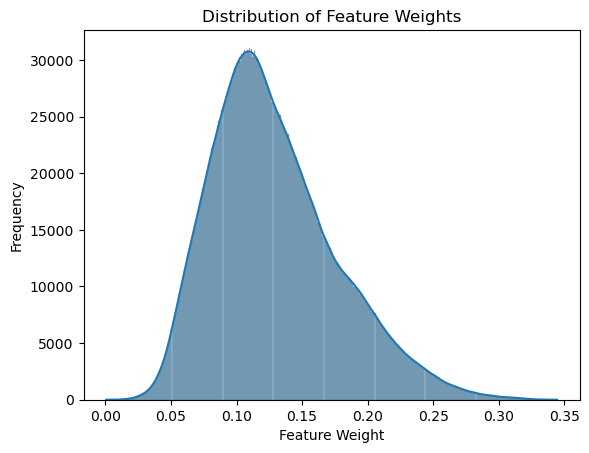

In [4]:
sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

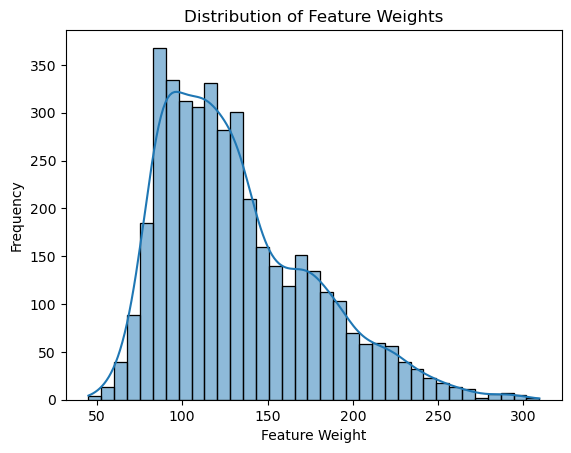

In [ ]:
sns.histplot(agg_feat_weights, kde=True)
plt.title('Distribution of Aggregate Feature Weights')
plt.xlabel('Aggregate Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Examining Feature Layer for Sparsity

In [6]:
autoencoder.predict_on_batch(fake_embeddings[:100])

(array([[0.11156362, 0.11921338, 0.12202924, ..., 0.11354829, 0.10771759,
         0.12201405],
        [0.11297098, 0.12011252, 0.12188511, ..., 0.115714  , 0.1081543 ,
         0.12229434],
        [0.11635001, 0.12357621, 0.12668736, ..., 0.11893696, 0.11210744,
         0.12684372],
        ...,
        [0.10925748, 0.11555812, 0.11832033, ..., 0.11096682, 0.10480082,
         0.11857364],
        [0.11624934, 0.12339114, 0.12610127, ..., 0.11850421, 0.11175567,
         0.12543084],
        [0.10981703, 0.11691251, 0.12022329, ..., 0.11171208, 0.10653777,
         0.12007777]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [7]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(fake_embeddings[:100])

In [8]:
reconstructed_outputs

array([[0.11156362, 0.11921338, 0.12202924, ..., 0.11354829, 0.10771759,
        0.12201405],
       [0.11297098, 0.12011252, 0.12188511, ..., 0.115714  , 0.1081543 ,
        0.12229434],
       [0.11635001, 0.12357621, 0.12668736, ..., 0.11893696, 0.11210744,
        0.12684372],
       ...,
       [0.10925748, 0.11555812, 0.11832033, ..., 0.11096682, 0.10480082,
        0.11857364],
       [0.11624934, 0.12339114, 0.12610127, ..., 0.11850421, 0.11175567,
        0.12543084],
       [0.10981703, 0.11691251, 0.12022329, ..., 0.11171208, 0.10653777,
        0.12007777]], dtype=float32)

In [9]:
feature_outputs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [10]:
feature_outputs[0].sort()
print(feature_outputs[0][-20:])
print(feature_outputs.shape)

[0.03090938 0.03106763 0.03167954 0.03256851 0.03304399 0.03557818
 0.0361885  0.03629097 0.03762437 0.03938087 0.0401171  0.04105567
 0.04447024 0.04795175 0.04859575 0.04879509 0.05027079 0.05241974
 0.05362756 0.05752014]
(100, 4096)


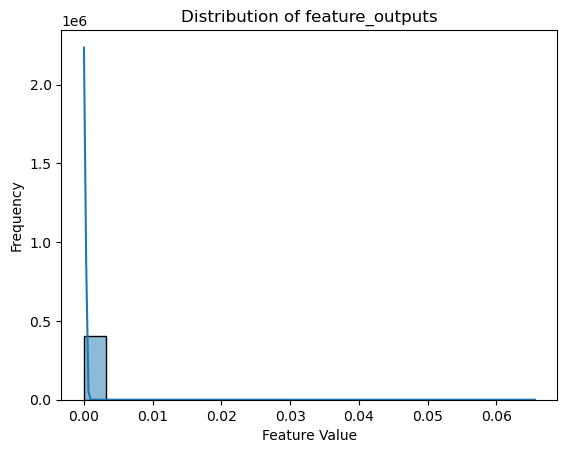

In [11]:
sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

### Check Model Fit / Overfit

In [12]:
# check model fit
fit_test_data = tf.random.uniform(shape=[100, embed_length])
fit_test_dataset = tf.data.Dataset.from_tensor_slices((fit_test_data, fit_test_data)).batch(10)

fit_test = autoencoder.evaluate(fit_test_dataset)
print(f"Loss: {fit_test[0]} | MSE: {fit_test[1]}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 85.5851 - mean_squared_error: 0.2271  
Loss: 85.58509063720703 | MSE: 0.22667747735977173


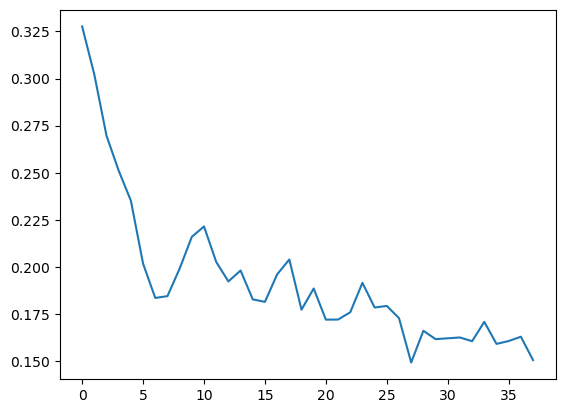

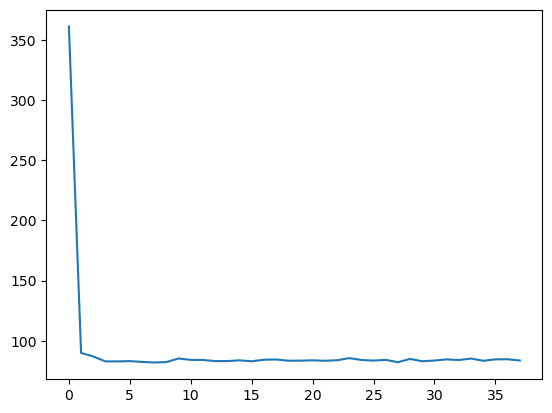

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['mean_squared_error'])
plt.show()
plt.plot(history.history['loss'])
plt.show()

In [14]:
# cleaning some memory
del fake_embeddings
del fake_dataset
del feat_weights
del reconstructed_outputs, feature_outputs, fit_test, fit_test_data, fit_test_dataset
del autoencoder, loss, metrics, optimizer, SAE_name, embed_length, ef, tb_callback, early_stopping, history, path

# SAE on ESM Embeddings for Hemoglobin Variants

Using the embeddings we previously generated from ESM-2, we're going to extract per-residue features based on the superposition hypothesis. After a bit of reformatting the data for this purpose, we should be able to train it to decompose the 1280-dimensional embeddings into a given number of features (number of neurons in the feature/2nd layer). The weights approximate the importance of those features.

In [15]:
# load metadata
var_data = pd.read_csv('./data/hbvar-w-func-embed-seq.csv')
# pandas saves these as strings for some reason - reload from numpy
var_data.drop(columns=['embeddings', 'sequence_representation', 'esm_representation'], inplace=True)
# drop stuff we don't need right now
var_data.drop(columns=[
    'electrophoresisComment',
    'hgvsName',
    'chromatography',
    'dnaDescriptionComment',
    'aliases',
    'stability',
    'functionalComment',
    'variantComment',
    'Structure',
    'electrophoresis',
    'name'
    ],
    inplace=True
)

# explicitly match embeddings to sequences when re-loading
embeddings = [np.load(f"./data/variant_embeddings/all_vars/{j}.npy") for j in var_data["sequence"]]

# reduce jagged tensors and add to dataframe
def fix_jagged_2d(embed_list):
    sir_gallahad_the_chaste = []
    # find max length in 2nd dim (sequence length)
    max_len = max([len(arr[0]) for arr in embed_list])
    # append zero vector to embeddings
    for i, arr in enumerate(embed_list):
        if len(arr[0]) < max_len:
            padded = np.append(arr[0], np.zeros((max_len - len(arr[0]), 1280)), axis=0)
            sir_gallahad_the_chaste.append(np.expand_dims(padded, axis=0))
        else:
            sir_gallahad_the_chaste.append(arr)
    return sir_gallahad_the_chaste

embeddings = np.concatenate(fix_jagged_2d(embeddings))
var_data['embeddings'] = embeddings
print(embeddings.shape)

(1206, 148, 1280)


In [16]:
# create dataset for training SAE
def pad_sequences(amino_acid_seq:str, pad_length:int):
    if len(amino_acid_seq)==pad_length:
        return amino_acid_seq
    else:
        return amino_acid_seq+''.join(['-' for i in range(pad_length-len(amino_acid_seq))])

residue_embeddings = np.vstack(embeddings)
residue_labels = ''.join([pad_sequences(i, 148) for i in var_data['sequence']])
print(residue_embeddings.shape)
print(len(residue_labels))

(178488, 1280)
178488


In [17]:
embed_data = pd.DataFrame(residue_embeddings)
embed_data["residues"] = [i for i in residue_labels]
ids = []
for x in var_data['sequence']:
    for n in range(148):
        ids.append(x)
embed_data["id"] = ids
embed_data

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,residues,id
0,0.039880,-0.060474,0.010107,0.036829,-0.108196,0.034697,0.064647,-0.159625,-0.046258,0.062892,...,-0.141350,0.002107,0.019046,-0.125863,-0.041022,-0.254396,0.179195,0.026323,M,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
1,0.080393,-0.052154,-0.171746,0.341434,0.078772,-0.058304,0.333229,-0.171261,-0.152863,0.206985,...,0.022498,0.101823,-0.029865,0.270576,-0.352361,0.134863,-0.125038,0.054623,G,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
2,-0.049513,0.014455,-0.113939,0.060111,-0.072646,-0.010627,0.273609,-0.318852,0.433905,0.061857,...,0.014927,0.150102,-0.240294,0.024542,0.329014,0.054479,0.119776,-0.048153,L,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
3,0.127423,-0.091589,0.235782,0.205985,0.035046,0.042871,0.346926,-0.112454,-0.497411,0.014614,...,-0.036321,0.142612,0.149523,-0.274964,0.304388,-0.278865,0.117745,-0.125761,S,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
4,-0.008895,-0.026455,-0.074877,0.359108,-0.062585,0.190984,0.031155,-0.140788,-0.187589,0.197234,...,0.101468,-0.070155,-0.134162,-0.248186,-0.223817,0.005409,-0.130158,-0.222160,P,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178483,-0.012570,0.155609,0.086157,0.203023,-0.189751,-0.219611,-0.089043,0.141252,-0.281113,0.286330,...,0.209440,-0.015287,-0.029175,0.007206,-0.113142,-0.114191,-0.199395,-0.126701,S,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178484,0.157495,0.253602,0.138182,0.164223,-0.114125,0.041772,-0.272245,0.024113,-0.052295,-0.014184,...,0.064878,0.118406,-0.092403,-0.098055,-0.239957,0.003924,-0.059399,-0.180254,R,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178485,0.039321,0.246502,0.044173,-0.037274,-0.029826,0.237742,-0.124555,0.027676,-0.236433,0.184976,...,0.077372,0.051368,0.180057,0.124684,-0.093465,-0.041433,0.026563,0.055376,Y,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178486,0.065609,-0.021404,-0.343105,0.312501,-0.192077,0.259709,0.161792,0.007382,-0.082263,-0.003792,...,0.114312,-0.013490,-0.047376,0.030331,-0.233131,-0.246021,-0.036705,0.138261,H,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...


In [18]:
embed_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
count,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,...,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000
mean,-0.000321,-0.089101,-0.127451,0.055683,-0.067626,0.003107,0.044247,-0.210164,-0.081553,0.128086,...,0.030794,-0.082786,0.025145,0.011804,-0.032353,-0.024557,0.035952,-0.113467,0.046954,0.052721
std,0.139333,0.181482,0.157588,0.155847,0.161549,0.156526,0.180078,0.177094,0.204604,0.152807,...,0.187289,0.168520,0.158767,0.160560,0.166029,0.186679,0.164430,0.174293,0.167026,0.173409
min,-0.544558,-0.771582,-0.727541,-0.494625,-0.637256,-0.515902,-0.580913,-0.771121,-0.806071,-0.316211,...,-0.514649,-0.829288,-0.665902,-0.449860,-0.636442,-0.539795,-0.503426,-0.703602,-0.750693,-0.491891
25%,-0.084041,-0.207170,-0.227538,-0.039479,-0.173615,-0.114964,-0.086407,-0.333480,-0.210472,0.019621,...,-0.096063,-0.186588,-0.088813,-0.103231,-0.138652,-0.162429,-0.069913,-0.220089,-0.073394,-0.061247
50%,0.007769,-0.079225,-0.107067,0.040565,-0.065167,0.007672,0.041899,-0.201495,-0.074380,0.128690,...,0.023891,-0.077323,0.028429,0.007233,-0.040593,-0.017941,0.031843,-0.108067,0.044187,0.055111
75%,0.091808,0.040356,-0.024260,0.146942,0.027864,0.112802,0.158992,-0.081739,0.050357,0.233646,...,0.139286,0.014959,0.138188,0.121978,0.075068,0.112806,0.151372,0.000000,0.159136,0.170518
max,0.447940,0.429185,0.379090,0.724625,0.479238,0.466639,0.679860,0.421257,0.595878,0.665754,...,0.870759,0.483314,0.559513,0.594107,0.544495,0.582657,0.625675,0.466966,0.573696,0.591184


In [19]:
# just in case we want to reload / use this later
embed_data.to_csv("./data/heme_SAE_train.csv")

### Training the SAE

In [20]:
# cleaning some memory
del embed_data, embeddings, var_data

In [21]:
# key parameters, model name
SAE_name = 'ESM-2-1280d-SAE-ef4'
embed_length = 1280
ef = 4

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.Metric(name='placeholder') # placeholder for training, feature output requires a 2nd metric to appease keras
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(
    x=residue_embeddings,
    y=residue_embeddings,
    batch_size=32, 
    epochs=100, 
    validation_split=0.1, 
    callbacks=[tb_callback, early_stopping]
    )

print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'

autoencoder.save(path)
autoencoder.save_weights(f'./models/{SAE_name}.weights.h5') # workaround via weight saving / loading

print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Initializing Model ===
=== Training Model ===
Epoch 1/100


2024-11-18 11:33:12.010690: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 16 bytes spill stores, 16 bytes spill loads

2024-11-18 11:33:12.016557: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 144 bytes spill stores, 144 bytes spill loads

2024-11-18 11:33:12.063220: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 4 bytes spill stores, 4 bytes spill loads



5005/5020 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29.0728 - mean_squared_error: 0.0731

2024-11-18 11:33:34.699781: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 4 bytes spill stores, 4 bytes spill loads

2024-11-18 11:33:35.182264: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 16 bytes spill stores, 16 bytes spill loads

2024-11-18 11:33:35.280433: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 44 bytes spill stores, 44 bytes spill loads

2024-11-18 11:33:35.377319: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_126', 176 bytes spill stores, 176 bytes spill loads



5020/5020 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29.0207 - mean_squared_error: 0.0731

...

 Total params: 39,321,602 (150.00 MB)

 Trainable params: 13,107,200 (50.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,214,402 (100.00 MB)

None


===== MSE =====


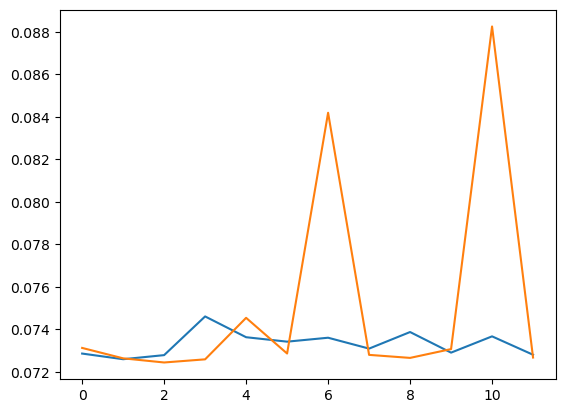

===== LOSS =====


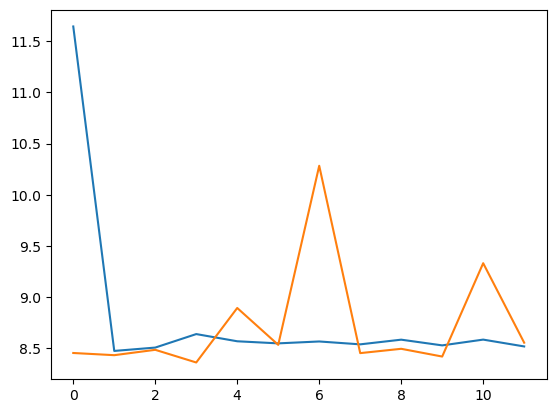

In [22]:
import matplotlib.pyplot as plt

print("===== MSE =====")
plt.plot(history.history['mean_squared_error'])
plt.plot(history.history['val_mean_squared_error'])
plt.show()

print("===== LOSS =====")
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()